In [1]:
from keras.models import load_model
from pathlib import Path
import joblib
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
import matplotlib.pyplot as plt


In [2]:
scalar = joblib.load(r'E:\NYISO_Project\dataset\scaler.joblib')
X_val = np.load(r'E:\NYISO_Project\dataset\X_val.npy')
y_val = np.load(r'E:\NYISO_Project\dataset\y_val.npy')
X_train = np.load(r'E:\NYISO_Project\dataset\X_train.npy')
y_train = np.load(r'E:\NYISO_Project\dataset\y_train.npy')

In [3]:
model = load_model(r'E:\NYISO_Project\models\load_forecasting.keras')

In [4]:
prediction_scaled = model.predict(X_val)
actual_load = scalar.inverse_transform(y_val.reshape(-1, 1))
predicted_load = scalar.inverse_transform(prediction_scaled)

273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [5]:
rmse = np.sqrt(mean_squared_error(actual_load, predicted_load))
mape = mean_absolute_percentage_error(actual_load, predicted_load)*100

In [6]:
print("\n--- Final 2025 Validation Results ---")
print(f"RMSE (Root Mean Square Error): {rmse:.2f} MW")
print(f"MAPE (Mean Absolute Percentage Error): {mape:.2f}%")


--- Final 2025 Validation Results ---
RMSE (Root Mean Square Error): 194.94 MW
MAPE (Mean Absolute Percentage Error): 0.84%


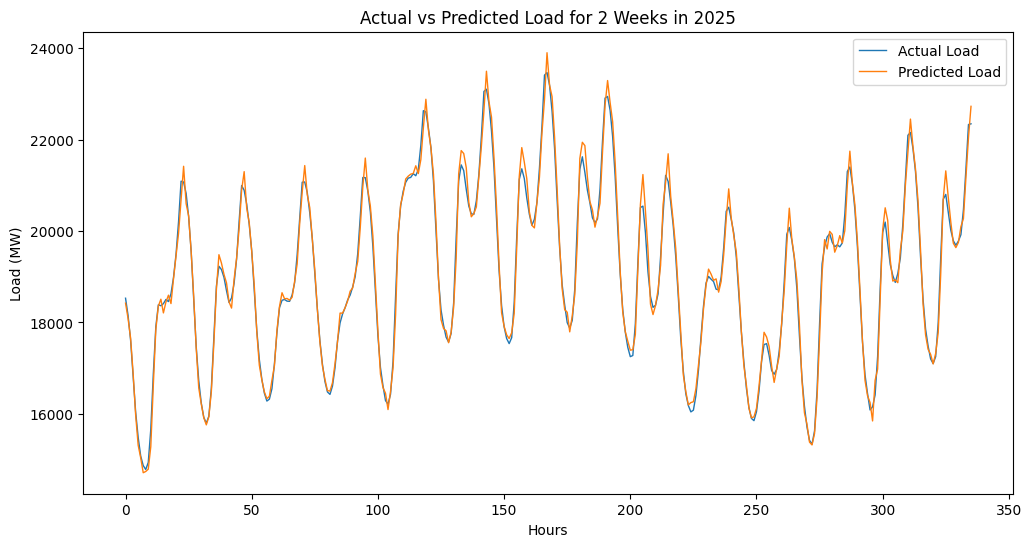

In [7]:
# Plotting actual vs predicted load for 2 weeks in 2025
hours_to_plot = 24 * 14  # 2 weeks of hourly data
plt.figure(figsize=(12, 6))
plt.plot(actual_load[:hours_to_plot], label='Actual Load', linewidth=1)
plt.plot(predicted_load[:hours_to_plot], label='Predicted Load', linewidth=1)
plt.xlabel('Hours')
plt.ylabel('Load (MW)')
plt.title('Actual vs Predicted Load for 2 Weeks in 2025')
plt.legend()
plt.show()

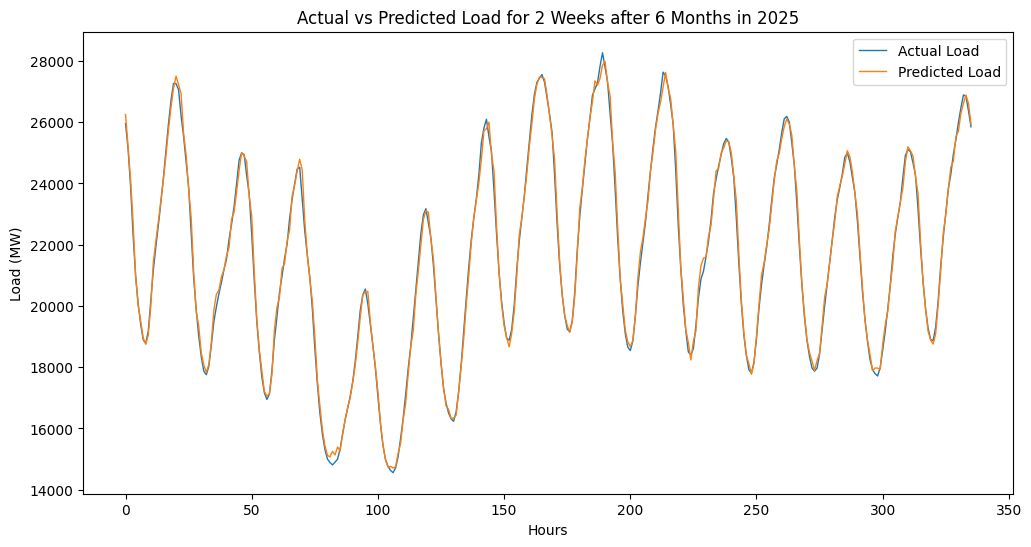

In [13]:
# Plotting prediction for two weeks after 6 months of 2025
start_hour = 24 * 30 * 6  # Starting after 6 months
plt.figure(figsize=(12, 6))
plt.plot(actual_load[start_hour:start_hour + hours_to_plot], label='Actual Load', linewidth=1)
plt.plot(predicted_load[start_hour:start_hour + hours_to_plot], label='Predicted Load', linewidth=1)
plt.xlabel('Hours')
plt.ylabel('Load (MW)')
plt.title('Actual vs Predicted Load for 2 Weeks after 6 Months in 2025')
plt.legend()